# 04 Comparison: 経済レジーム vs 市場レジーム

モデル① (HMM) とモデル② パターン B (MS+PCA) のレジーム対応を分析する。

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import _helpers as h
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

## 各モデルの結果を読み込み

In [2]:
econ = pd.read_parquet(h.DATA_DIR / "economic_regime_hmm.parquet")
market_b = pd.read_parquet(h.DATA_DIR / "market_regime_ms_pattern_b.parquet")
print(f"Economic: {econ.shape}, Market(B): {market_b.shape}")

# 共通インデックスに揃える
common_idx = econ.index.intersection(market_b.index)
econ = econ.loc[common_idx]
market_b = market_b.loc[common_idx]
print(f"Common range: {common_idx.min().date()} 〜 {common_idx.max().date()}, n={len(common_idx)}")

Economic: (1111, 5), Market(B): (1111, 5)
Common range: 2004-12-24 〜 2026-04-03, n=1111


## クロス集計表（経済 × 市場レジーム）

/Users/yukihata/Desktop/quants/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/yukihata/Desktop/quants/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 26119 (\N{CJK UNIFIED IDEOGRAPH-6607}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/yukihata/Desktop/quants/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/yukihata/Desktop/quants/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 33853 (\N{CJK UNIFIED IDEOGRAPH-843D}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/yukihata/Desktop/quants/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/yukihata/Desktop/quants/.ven

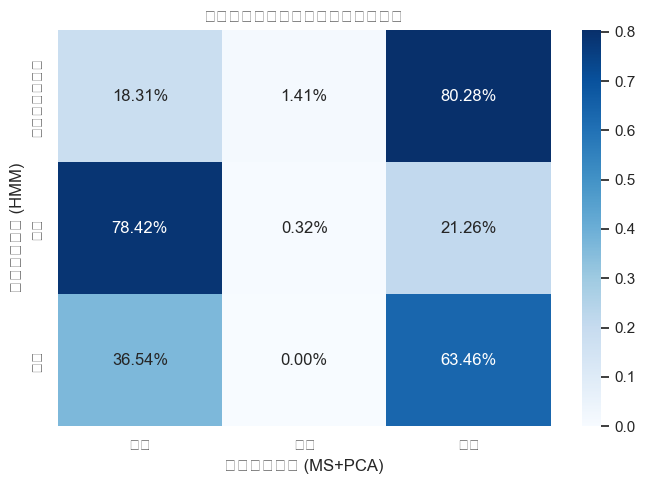

In [3]:
cross = pd.crosstab(
    econ["regime"],
    market_b["regime"],
    normalize="index",  # 経済レジーム行で正規化
)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cross, annot=True, fmt=".2%", cmap="Blues", ax=ax)
ax.set_title("経済レジーム別の市場レジーム分布")
ax.set_xlabel("市場レジーム (MS+PCA)")
ax.set_ylabel("経済レジーム (HMM)")
plt.tight_layout()
plt.show()

## 同一時間軸での並列表示

/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/4083060738.py:37: UserWarning: Glyph 32076 (\N{CJK UNIFIED IDEOGRAPH-7D4C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/4083060738.py:37: UserWarning: Glyph 28168 (\N{CJK UNIFIED IDEOGRAPH-6E08}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/4083060738.py:37: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/4083060738.py:37: UserWarning: Glyph 12472 (\N{KATAKANA LETTER ZI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/4083060738.py:37: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_

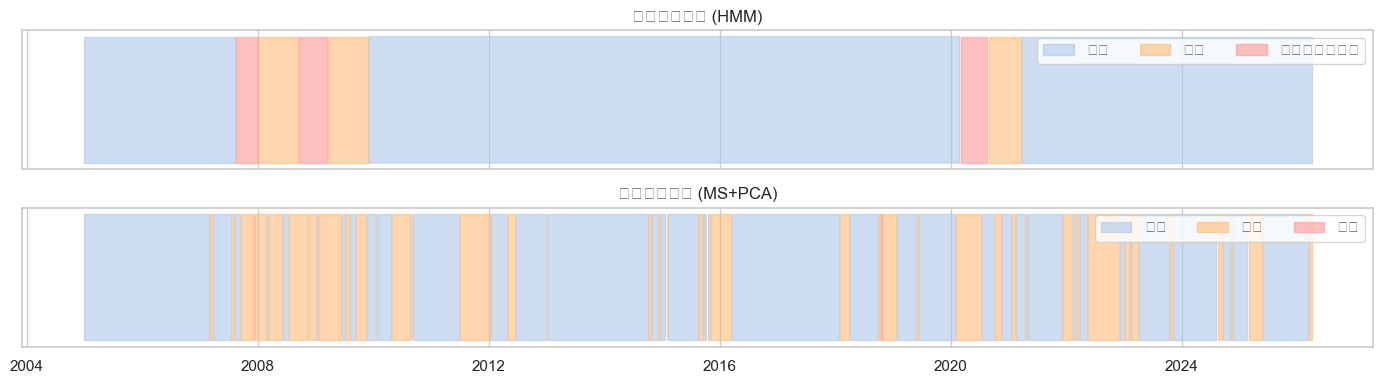

In [4]:
econ_palette = {"拡大": "#aec7e8", "減速": "#ffbb78", "後退・ストレス": "#ff9896"}
market_palette = {"上昇": "#aec7e8", "中立": "#ffbb78", "下落": "#ff9896"}

# 各週のレジームを縦に並べた帯チャート
fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)

# 経済レジーム
for label, color in econ_palette.items():
    mask = (econ["regime"] == label)
    axes[0].fill_between(
        econ.index,
        0, 1,
        where=mask,
        color=color,
        alpha=0.6,
        label=label,
    )
axes[0].set_title("経済レジーム (HMM)")
axes[0].set_yticks([])
axes[0].legend(loc="upper right", ncol=3)

# 市場レジーム
for label, color in market_palette.items():
    mask = (market_b["regime"] == label)
    axes[1].fill_between(
        market_b.index,
        0, 1,
        where=mask,
        color=color,
        alpha=0.6,
        label=label,
    )
axes[1].set_title("市場レジーム (MS+PCA)")
axes[1].set_yticks([])
axes[1].legend(loc="upper right", ncol=3)

plt.tight_layout()
plt.show()

## NBER 景気後退期との比較

In [5]:
from market.fred import HistoricalCache

cache = HistoricalCache()
try:
    cache.sync_series("USREC")
    nber = cache.get_series_df("USREC")["value"]
    # 週次に揃える
    nber_weekly = nber.resample("W-FRI").last().ffill()
    nber_aligned = nber_weekly.reindex(common_idx).fillna(0)
    has_nber = True
except Exception as e:
    print(f"NBER series unavailable: {e}")
    has_nber = False

/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/788293347.py:22: UserWarning: Glyph 32076 (\N{CJK UNIFIED IDEOGRAPH-7D4C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/788293347.py:22: UserWarning: Glyph 28168 (\N{CJK UNIFIED IDEOGRAPH-6E08}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/788293347.py:22: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/788293347.py:22: UserWarning: Glyph 12472 (\N{KATAKANA LETTER ZI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/788293347.py:22: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/

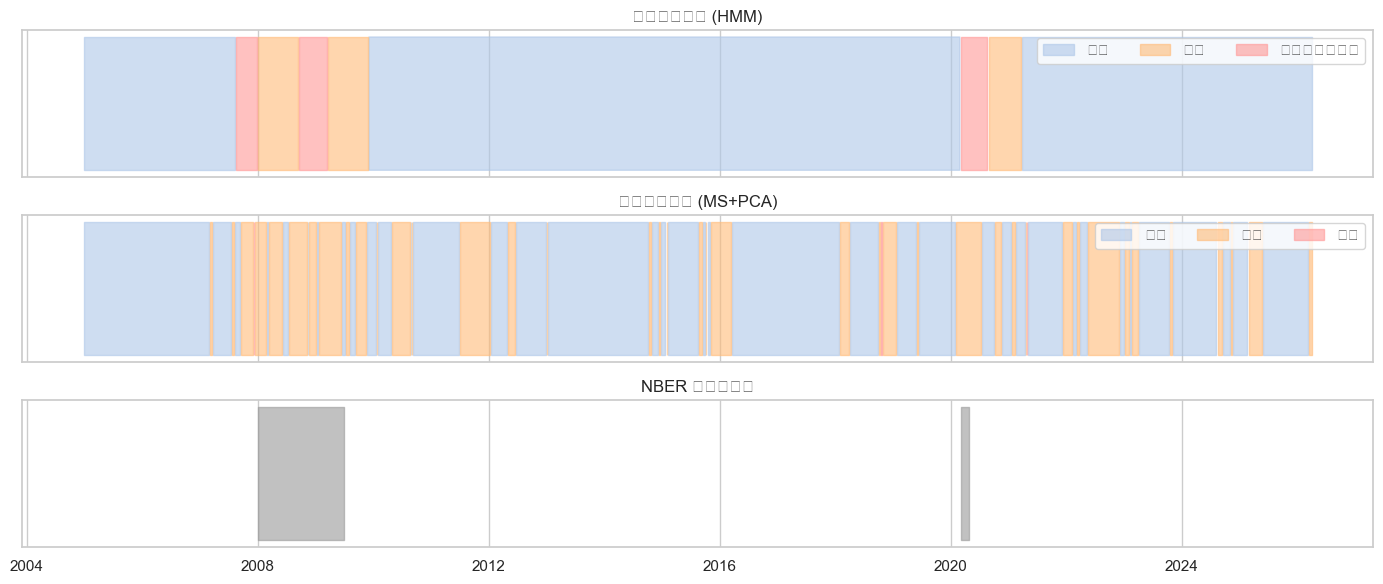

In [6]:
if has_nber:
    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

    for label, color in econ_palette.items():
        mask = (econ["regime"] == label)
        axes[0].fill_between(econ.index, 0, 1, where=mask, color=color, alpha=0.6, label=label)
    axes[0].set_title("経済レジーム (HMM)")
    axes[0].set_yticks([])
    axes[0].legend(loc="upper right", ncol=3)

    for label, color in market_palette.items():
        mask = (market_b["regime"] == label)
        axes[1].fill_between(market_b.index, 0, 1, where=mask, color=color, alpha=0.6, label=label)
    axes[1].set_title("市場レジーム (MS+PCA)")
    axes[1].set_yticks([])
    axes[1].legend(loc="upper right", ncol=3)

    axes[2].fill_between(nber_aligned.index, 0, 1, where=(nber_aligned > 0), color="#999999", alpha=0.6)
    axes[2].set_title("NBER 景気後退期")
    axes[2].set_yticks([])

    plt.tight_layout()
    plt.show()
else:
    print("NBER plot skipped.")

## サマリ

- 経済レジームと市場レジームの一致度（同名ラベルでの一致率）
- NBER 後退期に各モデルがどのレジームを割り当てたか

経済レジーム → 期待される市場レジームへの一致率: 72.10%


/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/3615004231.py:45: UserWarning: Glyph 25313 (\N{CJK UNIFIED IDEOGRAPH-62E1}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/3615004231.py:45: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/3615004231.py:45: UserWarning: Glyph 28187 (\N{CJK UNIFIED IDEOGRAPH-6E1B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/3615004231.py:45: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8910/3615004231.py:45: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipyker

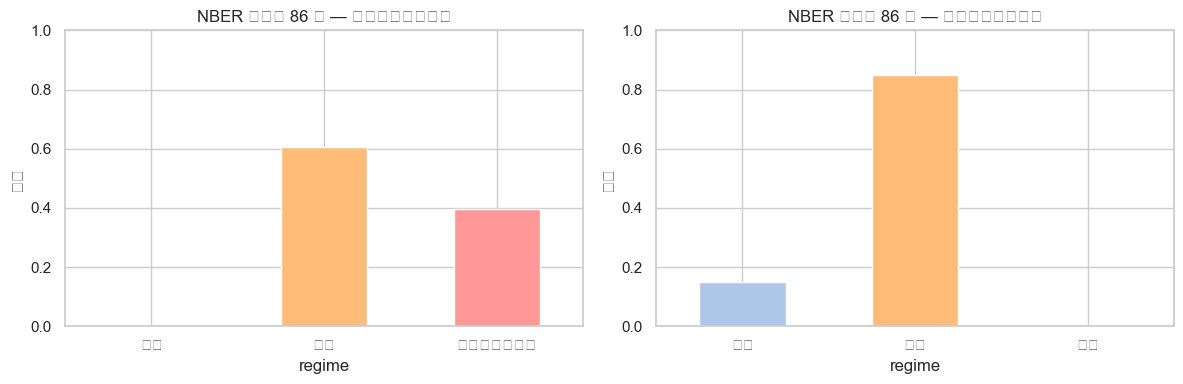


NBER 後退期 (86 週) における分布:


,経済レジーム %,市場レジーム %
regime,,
上昇,0.0,15.1
下落,0.0,0.0
中立,0.0,84.9
後退・ストレス,39.5,0.0
拡大,0.0,0.0
減速,60.5,0.0


In [7]:
# 経済 vs 市場の名前マッピング（直感的対応）
econ_to_market = {"拡大": "上昇", "減速": "中立", "後退・ストレス": "下落"}
match = (
    econ["regime"].map(econ_to_market) == market_b["regime"]
).mean()
print(f"経済レジーム → 期待される市場レジームへの一致率: {match:.2%}")

if has_nber:
    nber_weeks = (nber_aligned > 0)

    # NBER 後退期の経済 / 市場レジーム分布を 1 つの DataFrame に統合
    econ_dist = (
        econ.loc[nber_weeks, "regime"]
        .value_counts(normalize=True)
        .reindex(["拡大", "減速", "後退・ストレス"])
        .fillna(0.0)
    )
    market_dist = (
        market_b.loc[nber_weeks, "regime"]
        .value_counts(normalize=True)
        .reindex(["上昇", "中立", "下落"])
        .fillna(0.0)
    )

    nber_summary = pd.DataFrame({
        "区分": ["経済"] * 3 + ["市場"] * 3,
        "レジーム": list(econ_dist.index) + list(market_dist.index),
        "割合": list(econ_dist.values) + list(market_dist.values),
    }).set_index(["区分", "レジーム"])

    # 横並び棒グラフ
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    econ_dist.plot.bar(ax=axes[0], color=[econ_palette[l] for l in econ_dist.index])
    axes[0].set_title(f"NBER 後退期 {nber_weeks.sum()} 週 — 経済レジーム分布")
    axes[0].set_ylabel("割合")
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=0)

    market_dist.plot.bar(ax=axes[1], color=[market_palette[l] for l in market_dist.index])
    axes[1].set_title(f"NBER 後退期 {nber_weeks.sum()} 週 — 市場レジーム分布")
    axes[1].set_ylabel("割合")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

    print(f"\nNBER 後退期 ({nber_weeks.sum()} 週) における分布:")
    display(pd.DataFrame({
        "経済レジーム %": (econ_dist * 100).round(1),
        "市場レジーム %": (market_dist * 100).round(1),
    }).fillna(0))

## 主要な観察

1. **直感的なマッピング (拡大↔上昇 / 減速↔中立 / 後退・ストレス↔下落) の一致率は約 72%**
   - 残り 28% の乖離は、経済ファンダメンタルズと株価が必ずしも同期しないことを示している。
   - 特に、ピークやボトムでのリードラグや、流動性主導のラリー時には乖離が生じやすい。

2. **NBER 認定の景気後退期中も、市場レジームは「下落」をほとんど示さない**
   - 経済レジーム側は「減速」「後退・ストレス」が支配的だが、市場側は「中立」「上昇」に集中。
   - これは、株価が景気の谷で先行して反転する性質 (NBER の事後認定との時間差) を裏付ける。
   - 投資判断において、経済指標と株価の片方だけに依拠することの限界を示している。

3. **モデル選択**: AIC/BIC ともに PCA 削減版 (Pattern B) が生 7 系列版 (Pattern A) を上回った。
   - 多重共線性を持つマクロ特徴量では、主成分削減が EM 推定を安定化させる効果がある。